# Piloting hyperparameters using a representative patient

Piloting for moving window size $S$ for Adaptive Window BT-LDA and piloting for optimal UC-pair for Adaptive CC BT-LDA

In [1]:
import numpy as np
from utils.preprocessing import load_session_chached, merge_sessions
from utils.feature_extraction_v2 import load_features_chached_v2, merge_features


In [2]:
patient = 9
last_online = 17
calibration_selection="6D_long_350"

# merge data of all sessions

def merge_all_data_of_patient(patient,last_online, calibration_selection):

    if patient<10:
        patient_string = f"0{patient}"
    else:
        patient_string = f"{patient}"
        
    # start first with merging calibration sessions
    data_s1 = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S1/anonymized", selection = calibration_selection, discard_channels=True)
    data_s2 = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S2/anonymized", selection = calibration_selection, discard_channels=True)
    data_train = merge_sessions(data_s1, data_s2)

    calibration_selection_dc = f"{calibration_selection}_dc"
    features_s1 = load_features_chached_v2(f"B:_anonymized_data_P{patient_string}a_P{patient}_S1_anonymized{calibration_selection_dc}.pkl")
    features_s2 = load_features_chached_v2(f"B:_anonymized_data_P{patient_string}a_P{patient}_S2_anonymized{calibration_selection_dc}.pkl")
    features_train = merge_features(features_s1, features_s2)


    for session in range(3,last_online+1):
        data_new_session = load_session_chached(f"B:/anonymized_data/P{patient_string}a/P{patient}_S{session}/anonymized")
        data_train = merge_sessions(data_train, data_new_session)
        features_new_session = load_features_chached_v2(f"B:_anonymized_data_P{patient_string}a_P{patient}_S{session}_anonymized.pkl")
        features_train = merge_features(features_train, features_new_session)

    return data_train, features_train

def print_metadata_pilot(all_data, all_features):
    print(f"Metadata of pilot patient:")
    print(f"-------------------- Dataset --------------------")
    print(f"Total number of trials: {len(all_data.get('trials'))}")
    print(f"Total number of iterations: {len(all_data.get('iterations'))}")
    print(f"Total number of epochs: {len(all_data.get('epochs'))}")
    # print("Loaded files:")
    # for f in all_data.get('filenames'):
    #     print(f)
    print("-------------------- Preprocessing --------------------")
    for p in (all_data.get('preprocessing').keys()):
        print(f"{p}: {all_data.get('preprocessing').get(p)}")
    print("-------------------- Feature extraction --------------------")
    for p in (all_features.get('fe_info').keys()):
        print(f"{p}: {all_features.get('fe_info').get(p)}")



In [3]:
# test
patient = 9
last_online = 17
calibration_selection="6D_long_350"

all_data, all_features = merge_all_data_of_patient(patient,last_online, calibration_selection)

Loading file:  B:_anonymized_data_P09a_P9_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P09a_P9_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P09a_P9_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P09a_P9_S2_anonymized6D_long_350_dc.pkl
Not setting metadata
3240 matching events found


KeyboardInterrupt: 

In [ ]:
#print_metadata_pilot(all_data, all_features)
print((all_features.get('features'))[0].shape)

(1, 434)


In [76]:
# For pilot patient to find saturation point
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from toeplitzlda.classification import ToeplitzLDA
#from ERP_analysis_code.misc.pyclf.src.pyclf.lda.classification.toeplitzlda import ToeplitzLDA


def auc_datasizes_multisample(all_data, all_features, sizes = np.arange(90,900,90), 
                              #step_size = 90, 
                              tracker=False):

    #X = all_data.get('epochs')
    X = all_features.get('features')
    X = np.reshape(X, (X.shape[0],-1))
    print(X.shape)
    n_epochs_total = len(X)
    start = 0
    #stop = n_epochs_total
    stop = 60696 # until and incl s10
    print(f"Total epochs: {n_epochs_total}")
    print(f"Sizes: {sizes}")
    print(f"Range of data to sample from: [{start} : {stop}] (in # epochs)")

    trials=all_data.get('trials')
    y = [(1 if event > 107 else 0) for trial in trials for iteration in trial for event in iteration.events[:,2]]            
    y = np.array(y) # conversion to np array is maybe not even needed
    print(y.shape)
    
    scores = np.zeros(len(sizes))
    nch = (all_data.get('trials')[0][0]).info["nchan"]
    

    for s,size in enumerate(sizes):
        print(size)
        step = size
        size_scores = []
        #np.array([]) # btlda

        for j in range(start,stop,step):
            btlda = make_pipeline(ToeplitzLDA(n_channels=nch),)

            if tracker:
                print(f"\t interval: [{start+j},{start+j+size}] (out of [{start},{stop}])")

                size_scores.append(cross_val_score(btlda, X[start+j:start+j+size, :], y[start+j:start+j+size], cv=4, scoring='roc_auc').mean())

        print("FINAL scores of this size: ",size_scores)     
        scores[s] = np.mean(size_scores) 
        print("mean: ", np.mean(size_scores))  

    return scores       
    

In [54]:
print(print_metadata_pilot(all_data, all_features))

Metadata of pilot patient:
-------------------- Dataset --------------------
Total number of trials: 1302
Total number of iterations: 15840
Total number of epochs: 95040
-------------------- Preprocessing --------------------
filter_band: (0.5, 16)
non_eeg_channels: ['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic']
decimate: 10
montage: standard_1020
filter_method: iir
only_eeg: True
tmin: -0.2
tmax: 1
baseline: None
channels_to_discard: ['AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FT7', 'FC3', 'FCz', 'FC4', 'FT8', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPz', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO5', 'POz', 'PO6', 'PO8', 'Oz']
channels_to_use: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'F9', 'F10', 'P9', 'P10']
fs: 100.0
-------------------- Feature extraction --------------------
time_ivals: [0.1  0.15 0.2  0.25 0.3  0.35 0.4 

In [94]:
z = np.arange(1,10,1)
print(z)
p = z[0:len(z):2]
print(p)

[1 2 3 4 5 6 7 8 9]
[1 3 5 7 9]


1


<function matplotlib.pyplot.show(close=None, block=None)>

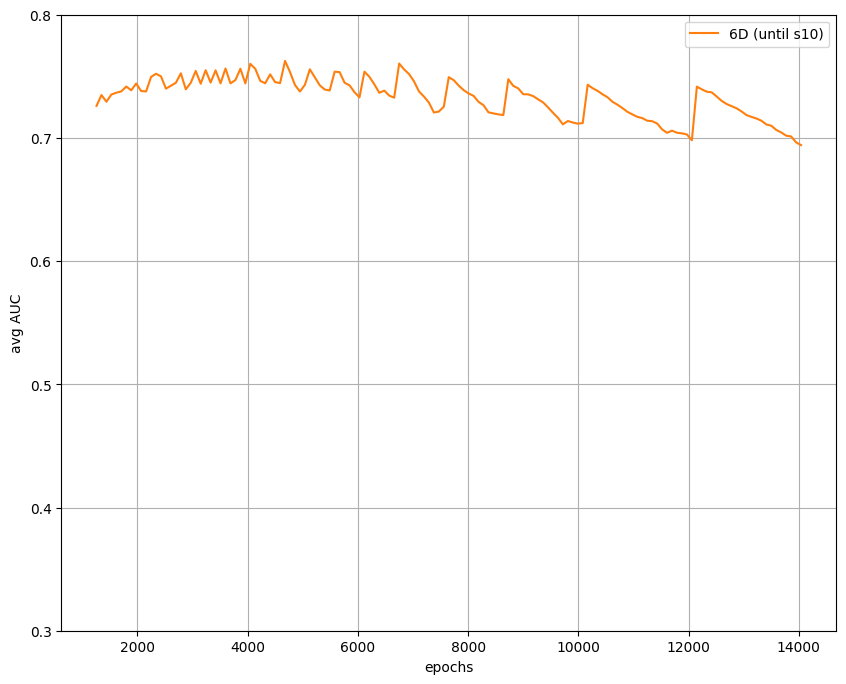

In [99]:
import matplotlib.pyplot as plt
print(len(sizes_medium_scores_6D[0:sizes_medium[-1]:600]))
plt.figure(figsize=(10,8))
plt.plot(sizes_medium,sizes_medium_scores_6D[0:len(sizes_medium)], label="6D (until s10)", color='tab:orange')
plt.ylim(0.3,0.8)
plt.grid()
#plt.xticks(sizes_medium)
plt.xlabel('epochs')
plt.ylabel('avg AUC')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

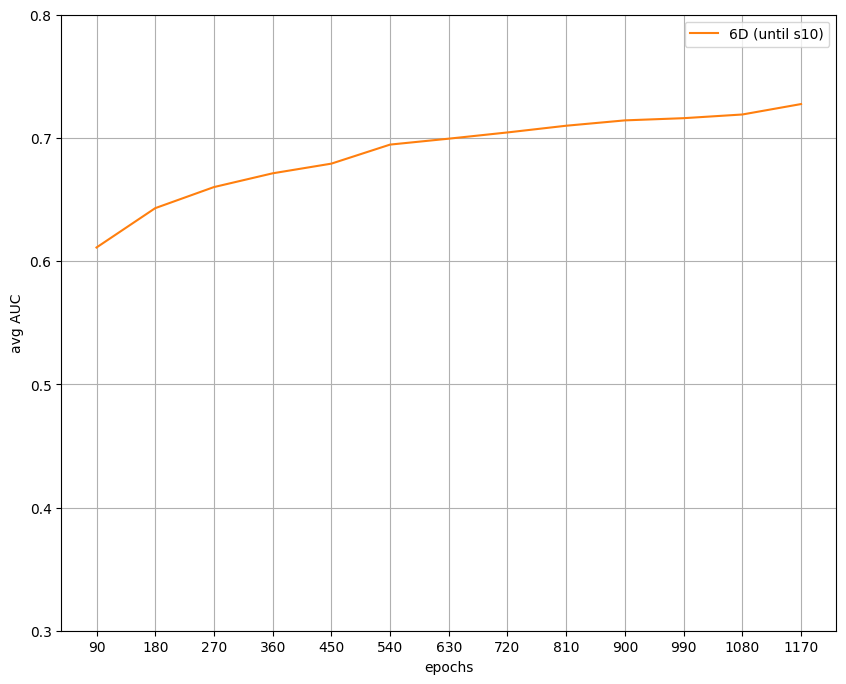

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.plot(sizes_small,sizes_small_scores_6D[:len(sizes_small)], label="6D (until s10)", color='tab:orange')
plt.ylim(0.3,0.8)
plt.grid()
plt.xticks(sizes_small)
plt.xlabel('epochs')
plt.ylabel('avg AUC')
plt.legend()
plt.show

In [80]:
np.save('v2sizes_medium_scores_6D.npy', sizes_medium_scores_6D)
np.save('v2sizes_medium.npy', sizes_medium)

In [79]:
sizes_medium = np.arange(1260,14100,90)
print(sizes_medium)
sizes_medium_scores_6D = auc_datasizes_multisample(all_data, all_features, sizes_medium, tracker=True)

[ 1260  1350  1440  1530  1620  1710  1800  1890  1980  2070  2160  2250
  2340  2430  2520  2610  2700  2790  2880  2970  3060  3150  3240  3330
  3420  3510  3600  3690  3780  3870  3960  4050  4140  4230  4320  4410
  4500  4590  4680  4770  4860  4950  5040  5130  5220  5310  5400  5490
  5580  5670  5760  5850  5940  6030  6120  6210  6300  6390  6480  6570
  6660  6750  6840  6930  7020  7110  7200  7290  7380  7470  7560  7650
  7740  7830  7920  8010  8100  8190  8280  8370  8460  8550  8640  8730
  8820  8910  9000  9090  9180  9270  9360  9450  9540  9630  9720  9810
  9900  9990 10080 10170 10260 10350 10440 10530 10620 10710 10800 10890
 10980 11070 11160 11250 11340 11430 11520 11610 11700 11790 11880 11970
 12060 12150 12240 12330 12420 12510 12600 12690 12780 12870 12960 13050
 13140 13230 13320 13410 13500 13590 13680 13770 13860 13950 14040]
(95040, 434)
Total epochs: 95040
Sizes: [ 1260  1350  1440  1530  1620  1710  1800  1890  1980  2070  2160  2250
  2340  2430  25